# Building Vocabularies and Corpora

## Estimated Time

- **CPU:** 30 minutes
- **GPU:** 30 minutes
- *Category: Medium*

## Overview

This tutorial teaches you how to extract molecular fragments from datasets and create custom vocabularies for your chemical space. You'll learn to build both vocabularies (merged, diverse fragments) and corpora (non-merged fragments for training).

## Prerequisites

- [x] GSGE installed (see [Installation Guide](../../docs/getting-started/installation.md))
- [ ] Basic understanding of SMILES notation
- [ ] Completed: None (beginner-friendly)

## Learning Objectives

By the end of this tutorial, you will be able to:
- Extract molecular fragments from datasets
- Create custom vocabularies for your chemical space
- Build corpora for GAE training
- Save and load vocabularies


# Building Molecular Fragment Vocabularies and Corpora

## Overview

This tutorial demonstrates how to build custom molecular fragment vocabularies using GSGE. You'll learn to:
- Create a **GSGE_Corpus** from molecules (for GAE training)
- Build a **GS_Vocab** for fragment-based representations
- Add custom fragments manually
- Visualize fragment coverage in molecules
- Validate and save your vocabularies

## Learning Objectives

By the end of this tutorial, you will be able to:
1. Extract molecular fragments from SMILES strings using custom bond-cutting rules
2. Understand the difference between GS_Vocab (merged) and GSGE_Corpus (non-merged)
3. Build vocabularies tailored to your chemical space
4. Add specific fragments to improve molecular coverage
5. Visualize how molecules are decomposed into fragments

## Prerequisites

- GSGE installed with dependencies
- Basic understanding of SMILES notation
- Familiarity with RDKit (helpful but not required)

## Table of Contents

- [1. Setup and Imports](#1-setup-and-imports)

- [2. Prepare Sample Data](#2-prepare-sample-data)

- [3. Building GSGE_Corpus](#3-building-gsge_corpus)

- [4. Building GS_Vocab](#4-building-gs_vocab)

- [5. Adding Custom Fragments](#5-adding-custom-fragments)

- [6. Creating Complete GSGE Instance](#6-creating-complete-gsge-instance)

- [7. Visualizing Fragment Coverage](#7-visualizing-fragment-coverage)

- [8. Validating Coverage](#8-validating-coverage)

- [9. Merging Vocabularies](#9-merging-vocabularies)

- [10. Saving Your Work](#10-saving-your-work)

---

## 1. Setup and Imports

First, import all required modules. We'll use:
- `GSGE_Corpus`: For building fragment corpora (non-merged, for GAE training)
- `GS_Vocab`: For building fragment vocabularies (merged, for compound graphs)
- `GSGE`: Main class that combines both
- `CUSTOM_fragment_mol`: Custom bond-cutting function for cyclic peptides and complex molecules

In [1]:
# Core GSGE imports
from GSGE import GSGE_Corpus, GS_Vocab, GSGE
from GSGE.fragment_functions import CUSTOM_fragment_mol
from GSGE.fragment_tools import Group

# RDKit for molecular manipulation
# from rdkit import Chem

# Standard libraries
# import random
# import pandas as pd
import os

## 2. Prepare Sample Data

For this tutorial, we'll use one of two approaches:

**Option A**: Load the pre-built vocabulary (quickest, recommended for first-time users)

**Option B**: Generate example molecules and build vocabulary from scratch

We'll demonstrate Option A here. If you want to build from scratch, uncomment the code in the next sections.

In [2]:
# Option A: Use pre-built vocabulary (RECOMMENDED)
# We'll load these in the next sections

# Option B: Generate example molecules
# Uncomment to create sample data:

# Example small molecules and peptides
example_smiles = [
    # Simple drug-like molecules
    'CC(C)Cc1ccc(cc1)C(C)C(=O)O',  # Ibuprofen
    'CC(=O)Oc1ccccc1C(=O)O',  # Aspirin
    'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',  # Caffeine
    
    # Linear peptides (2-4 amino acids)
    'CC(C)CC(N)C(=O)NCC(=O)O',  # Leu-Gly
    'NC(Cc1ccccc1)C(=O)NC(C)C(=O)O',  # Phe-Ala
    
    # Cyclic structures
    'C1CCC(CC1)C(=O)O',  # Cyclohexanecarboxylic acid
    'c1ccc2c(c1)ccc3c2cccc3',  # Anthracene
]

# If you have your own dataset, load it here:
# df = pd.read_csv('your_molecules.csv')
# example_smiles = df['SMILES'].tolist()

## 3. Building GSGE_Corpus

The `GSGE_Corpus` contains **non-merged, non-generalized** fragments extracted from molecules. These fragments are used to train the Graph Autoencoder (GAE).

### Key Parameters:

- `min_size`: Minimum number of heavy atoms in a fragment
- `max_size`: Maximum number of heavy atoms in a fragment
- `fragment_mol_fn`: Custom bond-cutting function (we use `CUSTOM_fragment_mol`)
- `fragmented=False`: Keep non-merged fragments (important for corpus)

### Process:

We'll load the pre-built corpus. If you want to build from scratch, uncomment the build code.

In [3]:
# Initialize corpus
GSGE_corpus = GSGE_Corpus()

# Option A: Load pre-built corpus (RECOMMENDED)
vocab_dir = os.path.join(os.path.dirname(os.path.abspath('')), '00_making_vocabs', 'vocabs')
corpus_path = os.path.join(vocab_dir, 'GSGE_corpus_v5')

if os.path.exists(corpus_path):
    GSGE_corpus.load_GSGE_corpus(corpus_path)
    print(f"[OK] Loaded corpus with {GSGE_corpus.num_fragments} fragments")
else:
    print("[!] Pre-built corpus not found. Building from example data...")
    # Build corpus from example molecules
    GSGE_corpus.build_corpus(
        example_smiles,
        min_size=1,
        max_size=15,
        method='default',
        fragment_mol_fn=CUSTOM_fragment_mol,
        convert=True,
        fragmented=False  # Keep non-merged fragments
    )
    print(f"[OK] Built corpus with {GSGE_corpus.num_fragments} fragments")

# Option B: Build from scratch with custom data
# Uncomment to build with your molecules:
#
# molecules = random.sample(example_smiles, min(1000, len(example_smiles)))
# GSGE_corpus.build_corpus(
#     molecules,
#     min_size=1,
#     max_size=15,
#     method='default',
#     fragment_mol_fn=CUSTOM_fragment_mol,
#     convert=True,
#     fragmented=False
# )
#
# # Save for future use
# GSGE_corpus.save_GSGE_corpus(
#     vocab_name='my_corpus',
#     meta_info='Custom corpus for my chemical space'
# )

Vocabulary loaded successfully!


100%|██████████| 8771/8771 [00:25<00:00, 344.47it/s]

[OK] Loaded corpus with 8771 fragments


In [4]:
GSGE_corpus.num_fragments

8771

### Expected Output:

You should see:
- A progress bar showing fragment extraction
- "Vocabulary loaded successfully!" message
- Number of fragments (typically 5,000-10,000 for diverse datasets)

In [5]:
# Visualize corpus statistics
GSGE_corpus.plot_vocab()

IntSlider(value=0, description='Page:', max=877)

Output()

### Understanding the Plot:

This histogram shows:
- **X-axis**: Fragment frequency (how many times each fragment appears)
- **Y-axis**: Number of fragments
- **Distribution**: Most fragments appear rarely; few fragments appear very frequently (Zipf's law)

## 4. Building GS_Vocab

The `GS_Vocab` contains **merged and generalized** fragments. These are used as nodes in compound graphs.

### Key Differences from Corpus:

- **Merging**: Similar fragments are combined
- **Generalization**: R-groups are collapsed (e.g., methyl and ethyl -> alkyl)
- **Size**: Much smaller than corpus (100-500 fragments)

### Building Strategy:

- `n_limit`: Keep top N most frequent fragments initially
- `target`: Target vocabulary size
- Algorithm iteratively merges until target size is reached

In [6]:
# Initialize vocabulary
GS_vocab = GS_Vocab()

# Option A: Load pre-built vocabulary (RECOMMENDED)
vocab_path = os.path.join(vocab_dir, 'GS_vocab_v5')

if os.path.exists(vocab_path):
    GS_vocab.load_GS_vocab(file_path=vocab_path)
    print(f"[OK] Loaded vocabulary with {GS_vocab.num_fragments} fragments")
else:
    print("[!] Pre-built vocabulary not found. Building from example data...")
    # Build vocabulary from example molecules
    GS_vocab.build_vocab(
        m_set=example_smiles,
        convert=True,
        n_limit=80,
        target=50,  # Smaller target for small dataset
        MIN_SIZE=1,
        MAX_SIZE=15,
        method='default',
        fragment_mol_fn=CUSTOM_fragment_mol
    )
    print(f"[OK] Built vocabulary with {GS_vocab.num_fragments} fragments")

# Option B: Build from scratch with custom data
# Uncomment to build with your molecules:
#
# random.seed(42)
# subset = random.sample(example_smiles, min(1000, len(example_smiles)))
# GS_vocab.build_vocab(
#     m_set=subset,
#     convert=True,
#     n_limit=80,
#     target=200,  # Larger target for diverse datasets
#     MIN_SIZE=1,
#     MAX_SIZE=15,
#     method='default',
#     fragment_mol_fn=CUSTOM_fragment_mol
# )
#
# # Save for future use
# GS_vocab.save_GS_vocab(
#     vocab_name='my_vocab',
#     meta_info='Custom vocabulary for my chemical space'
# )

Vocabulary loaded successfully!


100%|██████████| 127/127 [00:00<00:00, 393.99it/s]

[OK] Loaded vocabulary with 127 fragments


### Expected Output:

- Progress bar showing vocabulary construction
- "Vocabulary loaded successfully!" message
- Final vocabulary size (typically 100-200 fragments)

## 5. Adding Custom Fragments

Sometimes, the automatic fragmentation misses important functional groups. You can manually add fragments to improve coverage.

### Fragment Syntax:

- Use SMILES with `*1` to denote attachment points
- Examples:
  - `C=O(*1)`: Carbonyl group
  - `C(*1)(*1)`: Methylene bridge
  - `N(*1)(*1)`: Secondary amine

### Common Additions:

We add functional groups commonly found in organic molecules and peptides:

In [7]:
# Carbonyl and related groups
GS_vocab.add_GS_fragment('O=C(*1)(*1)')  # Carbonyl
GS_vocab.add_GS_fragment('S=C(*1)(*1)')  # Thiocarbonyl
GS_vocab.add_GS_fragment('S=C(*1)')      # Thione
GS_vocab.add_GS_fragment('N=C(*1)(*1)')  # Imine

# Sulfur/oxygen groups
GS_vocab.add_GS_fragment('O=S(*1)')      # Sulfinyl
GS_vocab.add_GS_fragment('O=S(*1)(*1)')  # Sulfonyl
GS_vocab.add_GS_fragment('C=S(*1)')      # Thiocarbonyl

# Double/triple bonds
GS_vocab.add_GS_fragment('C=C(*1)(*1)')    # Alkene
GS_vocab.add_GS_fragment('C(*1)(*1)=C(*1)(*1)')  # Disubstituted alkene
GS_vocab.add_GS_fragment('C=C=C(*1)(*1)')  # Allene
GS_vocab.add_GS_fragment('C#C(*1)')        # Alkyne

# Nitrogen groups
GS_vocab.add_GS_fragment('N(*1)(*1)')           # Secondary amine
GS_vocab.add_GS_fragment('N=C(*1)(*1)')         # Imine
GS_vocab.add_GS_fragment('*1N=N(*1)')           # Azo group
GS_vocab.add_GS_fragment('[N-]=[N+]=N(*1)')     # Azide
GS_vocab.add_GS_fragment('*1CN=[N+]=N')         # Diazo

# Phosphorus groups
GS_vocab.add_GS_fragment('O=P(*1)(*1)(*1)')  # Phosphate
GS_vocab.add_GS_fragment('O=P(*1)(*1)')      # Phosphonate

# Sulfur groups
GS_vocab.add_GS_fragment('S(=O)(=O)(*1)')  # Sulfone

# Simple connectors
GS_vocab.add_GS_fragment('C-O(*1)')  # Ether
GS_vocab.add_GS_fragment('C-N(*1)')  # Amine
GS_vocab.add_GS_fragment('C-S(*1)')  # Thioether

# Methyl/methylene
GS_vocab.add_GS_fragment('C(*1)(*1)')    # Methylene
GS_vocab.add_GS_fragment('CC(*1)(*1)')   # Ethylene
GS_vocab.add_GS_fragment('CC(*1)C')      # Isopropyl
GS_vocab.add_GS_fragment('CC(*1)O')      # Methoxy

# Halogens
GS_vocab.add_GS_fragment('Cl(*1)')  # Chloro
GS_vocab.add_GS_fragment('F(*1)')   # Fluoro
GS_vocab.add_GS_fragment('Br(*1)')  # Bromo
GS_vocab.add_GS_fragment('I(*1)')   # Iodo

# Single heteroatoms
GS_vocab.add_GS_fragment('O(*1)')  # Oxygen
GS_vocab.add_GS_fragment('S(*1)')  # Sulfur
GS_vocab.add_GS_fragment('N(*1)')  # Nitrogen

# Specialty groups
GS_vocab.add_GS_fragment('[SeH]C(*1)')  # Selenium

print(f"[OK] Added custom fragments. Total vocabulary size: {GS_vocab.num_fragments}")

[OK] Added custom fragments. Total vocabulary size: 154


### Note on Errors:

Some fragments may fail to add due to:
- Invalid SMILES syntax
- Valence violations
- RDKit parsing errors

These errors are expected and can be ignored. The fragments that successfully add will improve coverage.

In [8]:
# Check final vocabulary size
print(f"Final GS_Vocab size: {GS_vocab.vocab_fragments.__len__()} fragments")

Final GS_Vocab size: 154 fragments


### Example: Inspecting a Fragment

Let's look at what a fragment looks like:

Fragment name: test
Fragment SMILES: C(*1)(*1)
Fragment RDKit mol: <rdkit.Chem.rdchem.Mol object at 0x000001C2A3794AC0>


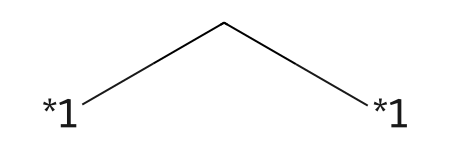

In [9]:
# Create a test fragment
group = Group('test', 'C(*1)(*1)')
print(f"Fragment name: {group.name}")
print(f"Fragment SMILES: {group.canonsmiles}")
print(f"Fragment RDKit mol: {group.mol}")

# Visualize (if in Jupyter)
group.mol

## 6. Creating Complete GSGE Instance

Now we combine the vocabulary and corpus into a complete GSGE instance. This object provides access to:
- Tokenization
- Compound graph generation
- Fragment embeddings (after GAE training)
- Visualization tools

In [10]:
# Create GSGE instance
gsge = GSGE(GS_vocab=GS_vocab, GSGE_corpus=GSGE_corpus)

# Add all single elements for complete coverage
# This ensures any atom can be represented, even if not in vocabulary
gsge.add_all_single_elements()

print(f"[OK] GSGE instance created")
print(f"  - GS_Vocab fragments: {gsge.get_GS_vocab().num_fragments}")
print(f"  - GSGE_Corpus fragments: {gsge.get_GSGE_corpus().num_fragments}")
print(f"  - Total unique fragments: {len(gsge.get_fragments_smiles())}")

Added single elements to GS_vocab
Added single elements to GSGE_corpus
[OK] GSGE instance created
  - GS_Vocab fragments: 200
  - GSGE_Corpus fragments: 8811
  - Total unique fragments: 200


### What are Single Elements?

Single elements (C, N, O, S, etc.) ensure 100% coverage. Even if a complex molecule can't be fully fragmented, individual atoms can be used as fallback fragments.

In [11]:
# Check total fragments (should be ~201 for pre-built vocab)
print(f"Total fragments available: {gsge.get_fragments_smiles().__len__()}")

Total fragments available: 200


## 7. Visualizing Fragment Coverage

One of the most powerful features of GSGE is visualizing how molecules are decomposed into fragments. This helps:
- Validate vocabulary coverage
- Understand fragmentation patterns
- Identify missing fragments

### Visualization Options:

- `img_size`: Image dimensions
- `verbose`: Print detailed information
- `color_method`: Coloring scheme ('method1' or 'standard')
- `annotate_with_index`: Show fragment indices
- `annotate_atoms`: Show atom numbers

[:0GS_frag_47][C][:1GS_frag_1][Ring1][:0GS_frag_76][Ring1][:0GS_frag_79][Ring1][:0GS_frag_76][Ring1][:0GS_frag_79][Ring1][:0GS_frag_47][pop][Ring1][Ring1][=C][pop][pop][pop][Ring1][:0GS_frag_47][pop][pop][pop][pop]
Molecule has 14 atoms
Group <Group GS_frag_1 N1=C(*1)N(*1)C(*1)=C1*1>: frag: [(3, 0), (2, 1), (1, 3), (5, 5), (4, 7)]
Group <Group GS_frag_76 O=C(*1)*1>: frag: [(7, 0), (6, 1)]
Group <Group GS_frag_76 O=C(*1)*1>: frag: [(10, 0), (9, 1)]
Group <Group GS_frag_47 C(*1)(*1)(*1)*1>: frag: [(0, 0)]
Group <Group GS_frag_47 C(*1)(*1)(*1)*1>: frag: [(12, 0)]
Group <Group GS_frag_47 C(*1)(*1)(*1)*1>: frag: [(13, 0)]
Group <Group GS_frag_79 N(*1)(*1)*1>: frag: [(8, 0)]
Group <Group GS_frag_79 N(*1)(*1)*1>: frag: [(11, 0)]


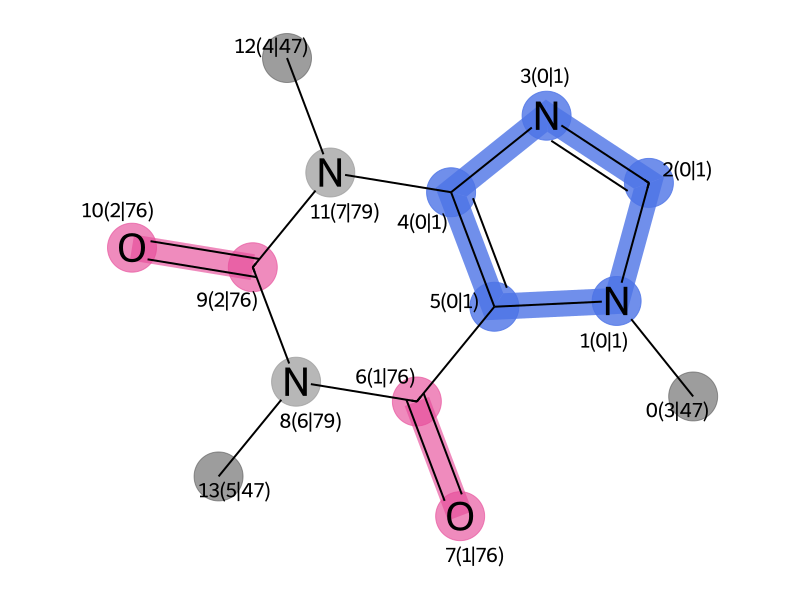

In [12]:
# Example molecule: caffeine
test_smiles = 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'

# Visualize fragment decomposition
gsge.plot_GS_fragments_in_mol(
    test_smiles,
    args={
        'img_size': (800, 600),
        'verbose': True,
        'color_method': 'method1',
        'color_seed': 42,
        'annotate_with_index': True,
        'annotate_atoms': True
    }
)

### Understanding the Visualization:

- **Different colors**: Each color represents a different fragment
- **Numbers**: Atom indices (if `annotate_atoms=True`)
- **Fragment indices**: Which fragment from vocabulary is used

### Try More Examples:

In [13]:
# Test with different molecules
test_molecules = [
    'CC(=O)Oc1ccccc1C(=O)O',  # Aspirin
    'CC(C)Cc1ccc(cc1)C(C)C(=O)O',  # Ibuprofen
    'NC(Cc1ccccc1)C(=O)O',  # Phenylalanine
]

for i, smiles in enumerate(test_molecules):
    print(f"\n=== Molecule {i+1}: {smiles} ===")
    gsge.plot_GS_fragments_in_mol(
        smiles,
        args={
            'img_size': (800, 600),
            'verbose': True,
            'color_method': 'method1',
            'annotate_with_index': True
        }
    )


=== Molecule 1: CC(=O)Oc1ccccc1C(=O)O ===
[:0GS_frag_47][C][:0GS_frag_76][Ring1][:0GS_frag_0][Ring1][:2GS_frag_68][Branch][:0GS_frag_76][Ring1][:0GS_frag_0][pop][pop][pop][pop][pop]
Molecule has 13 atoms
Group <Group GS_frag_68 C1=C(*1)C=C(*1)C(*1)=C1*1>: frag: [(6, 0), (7, 1), (8, 3), (9, 4), (4, 6), (5, 8)]
Group <Group GS_frag_76 O=C(*1)*1>: frag: [(2, 0), (1, 1)]
Group <Group GS_frag_76 O=C(*1)*1>: frag: [(11, 0), (10, 1)]
Group <Group GS_frag_0 O(*1)*1>: frag: [(3, 0)]
Group <Group GS_frag_0 O(*1)*1>: frag: [(12, 0)]
Group <Group GS_frag_47 C(*1)(*1)(*1)*1>: frag: [(0, 0)]

=== Molecule 2: CC(C)Cc1ccc(cc1)C(C)C(=O)O ===
[:0GS_frag_122][O][:0GS_frag_47][Ring1][:0GS_frag_68][Ring2][:3GS_frag_125][Ring2][:0GS_frag_0][pop][pop][pop][pop]
Molecule has 15 atoms
Group <Group GS_frag_68 C1=C(*1)C=C(*1)C(*1)=C1*1>: frag: [(5, 0), (4, 1), (9, 3), (8, 4), (7, 6), (6, 8)]
Group <Group GS_frag_125 O=C(C(C(*1)(*1)*1)(*1)*1)*1>: frag: [(13, 0), (12, 1), (10, 2), (11, 3)]
Group <Group GS_frag_12

## 8. Validating Coverage

It's important to check that your vocabulary can represent all molecules in your dataset. The `check_for_graphs_groupings()` function validates this.

In [14]:
# Test on example molecules
test_set = example_smiles[:10] if len(example_smiles) > 0 else [
    'CCO',
    'CC(=O)O',
    'c1ccccc1',
    'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'
]

results = gsge.check_for_graphs_groupings(test_set)

print(f"\n[OK] Coverage check complete")
print(f"  - Molecules tested: {len(test_set)}")
print(f"  - All molecules covered: {len(results) == 0}")

# Show any problematic molecules
if results:
    print(f"\n[!] {len(results)} molecules not fully covered:")
    for idx, ungrouped_atoms, smiles in results:
        print(f"  - Index {idx} ({smiles}): {len(ungrouped_atoms)} ungrouped atoms")
else:
    print("\n[OK] All molecules are fully covered by the vocabulary!")

parallel_tokenize_batch: 100%|██████████| 7/7 [00:54<00:00,  7.82s/it]



[OK] Coverage check complete
  - Molecules tested: 7
  - All molecules covered: True

[OK] All molecules are fully covered by the vocabulary!


### Troubleshooting Coverage Issues:

If molecules aren't covered:
1. Add more specific fragments manually
2. Adjust `MIN_SIZE` and `MAX_SIZE` when building vocabulary
3. Use `add_all_single_elements()` for guaranteed coverage

## 9. Merging Vocabularies

The GS_Vocab and GSGE_Corpus contain different fragments:
- **GS_Vocab**: Merged fragments (smaller set)
- **GSGE_Corpus**: Non-merged fragments (larger set)

We can add GS_Vocab fragments to the corpus to ensure complete coverage during GAE training:

In [15]:
# Check fragment counts before merging
print(f"Before merging:")
print(f"  - GSGE_Corpus fragments: {GSGE_corpus.num_fragments}")
print(f"  - GS_Vocab fragments: {GS_vocab.num_fragments}")

# Find fragments in GS_Vocab but not in GSGE_Corpus
gs_hashes = set(GS_vocab.hash_to_frag_info.keys())
gsge_hashes = set(GSGE_corpus.hash_to_frag_info.keys())
missing_hashes = gs_hashes - gsge_hashes

print(f"  - Fragments in GS_Vocab missing from Corpus: {len(missing_hashes)}")

# Add GS_Vocab fragments to corpus
gsge.add_GS_vocab_to_GSGE_corpus()

print(f"\nAfter merging:")
print(f"  - GSGE_Corpus fragments: {GSGE_corpus.num_fragments}")

Before merging:
  - GSGE_Corpus fragments: 8811
  - GS_Vocab fragments: 200
  - Fragments in GS_Vocab missing from Corpus: 80

After merging:
  - GSGE_Corpus fragments: 8891


### Why Merge?

Merging ensures that:
- All fragments used in compound graphs are also in the corpus
- GAE training covers all fragments that will be used downstream
- No "unknown fragment" issues occur during inference

## 10. Saving Your Work

After building and validating your vocabularies, save them for future use:

In [16]:
# Option 1: Save individual components
# Uncomment to save:

# GS_vocab.save_GS_vocab(
#     vocab_name='my_GS_vocab',
#     meta_info='Custom GS_Vocab for my chemical space'
# )

# GSGE_corpus.save_GSGE_corpus(
#     vocab_name='my_GSGE_corpus',
#     meta_info='Custom GSGE_Corpus for GAE training'
# )

# Option 2: Save complete GSGE instance (RECOMMENDED)
# This saves everything in one file

# gsge.save_gsge_data(
#     filepath='my_gsge_complete.pkl',
#     meta_info='Complete GSGE with vocabulary and corpus'
# )

print("[OK] Ready to save! Uncomment the code above to save your vocabularies.")

[OK] Ready to save! Uncomment the code above to save your vocabularies.


### Loading Saved Data:

```python
# Load complete GSGE
from GSGE import GSGE
gsge_loaded = GSGE(GSGE_load_path='my_gsge_complete.pkl')

# Or load individual components
from GSGE import GS_Vocab, GSGE_Corpus
vocab = GS_Vocab()
vocab.load_GS_vocab('my_GS_vocab')
corpus = GSGE_Corpus()
corpus.load_GSGE_corpus('my_GSGE_corpus')
```

---

## Summary

In this tutorial, you learned:

[OK] **Building GSGE_Corpus**: Extract non-merged fragments for GAE training

[OK] **Building GS_Vocab**: Create merged fragment vocabulary for compound graphs

[OK] **Adding Custom Fragments**: Manually add important functional groups

[OK] **Visualizing Coverage**: See how molecules decompose into fragments

[OK] **Validating**: Check that all molecules can be represented

[OK] **Merging**: Combine vocabularies for complete coverage

[OK] **Saving**: Preserve your work for future use

## Next Steps

Now that you have vocabularies, you can:

1. **Train GAE**: Use GSGE_Corpus to train the Graph Autoencoder
   - See: [`GAE Tutorial`](../03_GAE/README.md)

2. **Create Compound Graphs**: Use GS_Vocab to represent molecules as graphs
   - See: [`Compound Graphs Tutorial`](../01_make_compound_graphs/README.md)

3. **Tokenization**: Convert molecules to fragment sequences
   - See: [`Tokenization Tutorial`](../02_tokenization_example/README.md)

## Additional Resources

- [Tutorial README](README.md) - Overview and quick start
- [Main Documentation](../../docs/index.md) - Complete GSGE documentation
- [API Reference](../../docs/api-reference/index.md) - Detailed API docs

---

**Questions or issues?** Open an issue on [GitHub](https://github.com/CDDLeiden/GSGE/issues)